In [1]:
%pip install torch numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Contextualização histórica e motivação
Esta seção introduz o problema que motivou o desenvolvimento das camadas de normalização e conecta a teoria ao estado atual da área em 2024-2025.

Camadas de normalização estão presentes em praticamente todos os modelos de deep learning, figurando em blocos fundamentais de arquiteturas modernas como os Transformers, que intercalam mecanismos de atenção e de feedforward com processos de normalização. O objetivo principal dessas camadas é alterar a distribuição dos dados intermediários nas redes neurais, forçando os tensores a operarem com uma média centrada em zero e um desvio padrão igual a um. Historicamente, o treinamento de redes profundas sofria com instabilidades severas geradas por mudanças frequentes na distribuição ("covariate shift") e por problemas clássicos de gradientes que desaparecem (vanishing gradients) e gradientes que explodem (exploding gradients).

A aplicação metódica da normalização minimiza essas anomalias e diminui significativamente a instabilidade intrínseca do treinamento. Além das motivações matemáticas, as GPUs modernas são otimizadas nativamente para processar com eficiência máxima dados distribuídos com média zero e desvio padrão um, o que minimiza erros numéricos de cálculo e acelera drasticamente a convergência dos algoritmos. Os mesmos requisitos de escala controlada são fundamentais para técnicas de quantização.

No cenário atual de inteligência artificial (2025), a evolução algorítmica consolidou métodos de menor custo computacional, como o RMSNorm, padrão na vasta maioria dos grandes modelos de linguagem (LLMs) otimizados. Simultaneamente, inovações muito recentes e experimentais, como a Tangente Hiperbólica Dinâmica (Dynamic Tanh) proposta pela Meta no início de 2025, procuram substituir o cálculo computacional de métricas estatísticas (média e variância) por aproximações não lineares extremamente eficientes.

## 2. Intuição e visualização
Esta seção constrói a intuição geométrica e estatística do processo de normalização antes do rigor matemático das fórmulas.

Observe que a simples aplicação de uma camada de normalização não transforma os dados originais magicamente em uma distribuição normal de Gauss. O processo matemático apenas aplica um deslocamento contínuo (shift) na média dos dados e um redimensionamento (scale) restrito ao seu desvio padrão. Desta forma, caso a distribuição dos dados originais obedeça a um formato exponencial, a distribuição normalizada preservará visualmente e estatisticamente esse comportamento exponencial, passando apenas a atuar centrada na origem (zero).

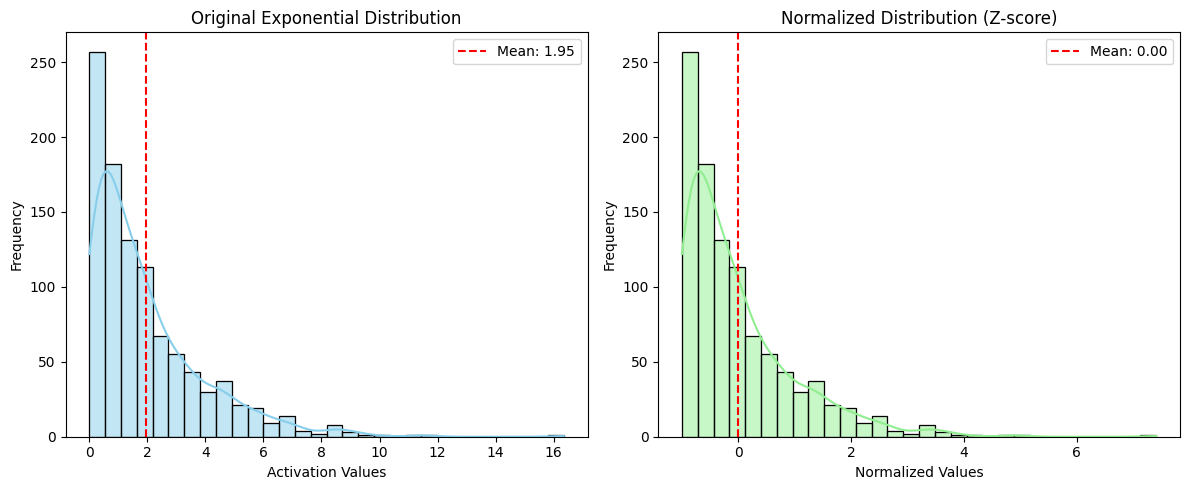

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Generate exponential data (simulate non-normal raw activations)
raw_data = np.random.exponential(scale=2.0, size=1000)

# Calculate statistics
mean_raw = np.mean(raw_data)
std_raw = np.std(raw_data)

# Standardize (Z-score normalization)
normalized_data = (raw_data - mean_raw) / std_raw

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(raw_data, bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Original Exponential Distribution')
axes[0].set_xlabel('Activation Values')
axes[0].set_ylabel('Frequency')
axes[0].axvline(mean_raw, color='red', linestyle='--', label=f'Mean: {mean_raw:.2f}')
axes[0].legend()

sns.histplot(normalized_data, bins=30, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Normalized Distribution (Z-score)')
axes[1].set_xlabel('Normalized Values')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', label='Mean: 0.00')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Teoria formal
Esta seção apresenta as formulações matemáticas rigorosas das principais estratégias de normalização para deep learning.

A normalização pioneira, conhecida estritamente como normalização Z-score, realiza a padronização baseada na fórmula estatística fundamental:
$$X_{norm} = \frac{X - \mu}{\sigma}$$
Esse cálculo elementar assegura que o vetor de saída apresente média matemática nula e uma variância global igual a um. No contexto restrito de redes neurais, a técnica original **Batch Normalization** adapta essa lógica computando a média e a variância isoladamente dentro da amostragem de um mini-batch. Para garantir forte estabilidade numérica, um termo ínfimo de erro ($\epsilon$) é adicionado à variância. Em seguida, aplica-se uma transformação afim através de parâmetros aprendíveis $\gamma$ (escala) e $\beta$ (deslocamento). A formulação matemática obedece à equação:
$$x_{norm} = \gamma \frac{x - \mu_{batch}}{\sqrt{\sigma_{batch}^2 + \epsilon}} + \beta$$

Uma limitação severa da Batch Normalization surge no uso com lotes muito pequenos, situação em que a altíssima flutuação estatística gera aguda instabilidade no aprendizado da rede. Um problema adicional se dá pelo fato de que as métricas estatísticas geradas na fase de treinamento divergem criticamente daquelas usadas em inferência.

Para contornar estas barreiras estruturais, a arquitetura da **Layer Normalization** atua executando o cálculo por amostra de forma autônoma, agregando estatisticamente todos os canais ou posições latentes da camada simultaneamente. Essa dinâmica isola perfeitamente os valores em fases distintas, impedindo diferenças entre o momento de treino e a validação do modelo. Devido a essa resiliência, converteu-se na espinha dorsal de algoritmos para processamento de linguagem natural e Transformers. Abordagens afins como a **Instance Normalization** (cálculo por amostra em cada canal específico) e a **Group Normalization** (cálculo amostral particionado por pequenos blocos de canais) mantêm a mesma base algébrica, porém direcionadas a resolver estabilidades extremas em processamento de imagens e pequenos batches de CNNs.

Em contínua busca por otimização, o protocolo da **RMSNorm** introduz computação significantemente mais leve frente à Layer Normalization tradicional. O processo dispensa por completo a computação da média do vetor, dividindo o valor original unicamente pela raiz da média dos seus termos ao quadrado (Root Mean Square):
$$x_{norm} = \gamma \frac{x}{\sqrt{\frac{1}{N} \sum_{i=1}^N x_i^2 + \epsilon}}$$
Esta função dita o comportamento formal para os modernos modelos de linguagem baseados em Transformers amplamente implantados hoje.

Por fim, rompendo o próprio raciocínio da padronização estatística vetorial, em 2025 o framework da **Dynamic Tanh** emergiu como um paradigma experimental proposto pela Meta. Analisando os espaços multidimensionais, pesquisadores notaram que a saída intrínseca destas camadas tende progressivamente a simular as propriedades matemáticas da curva em S da tangente. Ao invés de usar métodos estatísticos demorados, aplica-se a função tangente hiperbólica atrelada a uma variável adaptativa aprendível $\alpha$:
$$x_{norm} = \gamma \tanh(\alpha x) + \beta$$
Este processo remove radicalmente qualquer redução ou agregação por médias, provendo altíssima velocidade para instâncias futuras.

## 4. Algoritmos
Esta seção explícita as etapas procedimentais e o controle de fluxo computacional para a normalização RMSNorm.

O pseudocódigo abaixo decompõe os cálculos paralelos necessários em uma unidade de processamento para realizar a modernização RMSNorm sem recorrer a laços interativos lentos.

```text
Entrada:
    X: Matriz de ativação (Lote x Dimensão)
    gamma: Vetor de parâmetros aprendidos (escala)
    epsilon: Constante pequena para evitar divisão por zero

Algoritmo RMSNorm(X, gamma, epsilon):
    1. Calcula o quadrado de todos os elementos da matriz X, elemento a elemento.
    2. Agrupa os elementos ao longo da Dimensão do vetor.
    3. Calcula a média aritmética de todos os itens elevados ao quadrado (Root Mean).
    4. Adiciona a constante epsilon ao valor da média para segurança numérica.
    5. Computa a raiz quadrada matemática do valor encontrado no passo 4 (Square).
    6. Divide a matriz de ativação original X pelo resultado do passo 5.
    7. Multiplica o resultado do passo 6 pelo vetor de escala gamma.
    8. Retorna a matriz final.
```

## 5. Implementação from scratch
Esta seção traduz as definições matemáticas essenciais mediante implementações puras utilizando exclusivamente operações vetoriais Numpy (sem o auxílio de grafos automáticos de bibliotecas de DL).

Note a inicialização cuidadosa da variável $\gamma$ (como um vetor de 1s) na implementação.

In [3]:
import numpy as np

class NumpyRMSNorm:
    """
    Implementação from scratch da Root Mean Square Layer Normalization (RMSNorm).
    Assume como entrada um tensor 2D de formato (batch_size, num_features).
    """
    def __init__(self, num_features, eps=1e-8):
        self.eps = eps
        self.num_features = num_features
        # O parâmetro gama (escala) inicia em 1. Não há beta (deslocamento) padrão na RMSNorm.
        self.gamma = np.ones((1, num_features))

    def forward(self, x):
        # Passo 1, 2, 3: Média do quadrado dos elementos ao longo da dimensão de features (axis=1)
        # O keepdims=True garante que o vetor resultante possa ser usado em operações de broadcast na divisão.
        mean_squared = np.mean(x ** 2, axis=1, keepdims=True)

        # Passo 4, 5: Inclusão do epsilon e cálculo da raiz quadrada
        rms = np.sqrt(mean_squared + self.eps)

        # Passo 6, 7: Divisão e aplicação da escala gamma
        x_norm = (x / rms) * self.gamma
        return x_norm

# --- Teste / Assert ---
np.random.seed(42)
dummy_input = np.random.randn(4, 128)  # Batch de 4 amostras, 128 dimensões
rms_norm = NumpyRMSNorm(num_features=128)
output = rms_norm.forward(dummy_input)

# Teste de propriedade: Na RMSNorm, a magnitude (RMS) pós-normalização sem considerar gamma deve ser 1.
rms_output = np.sqrt(np.mean(output ** 2, axis=1))
assert np.allclose(rms_output, 1.0, atol=1e-5), 'O RMS da saída normalizada deve ser muito próximo a 1.'
print('Implementação NumpyRMSNorm validada com sucesso.')

Implementação NumpyRMSNorm validada com sucesso.


## 6. Implementação em PyTorch
Esta seção reescreve a lógica apresentada no contexto dinâmico do PyTorch e mapeia as primitivas do framework nativo para o conceito matemático subjacente.

O PyTorch disponibiliza a API torch.nn.RMSNorm, que encapsula diretamente as funções vistas anteriormente. A implementação da classe exposta atua replicando o comportamento interno destas APIs de forma rastreável. Observe que o parâmetro nn.Parameter converte nosso tensor de escala gamma em uma variável ativa mapeada para a diferenciação automática.

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class TorchCustomRMSNorm(nn.Module):
    """
    Reimplementação completa da RMSNorm em PyTorch puro.
    """
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        # Define gamma como um parâmetro otimizável da rede neural
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # A API torch.mean é utilizada na última dimensão (-1).
        norm_x = torch.mean(x.pow(2), dim=-1, keepdim=True)
        x_normed = x * torch.rsqrt(norm_x + self.eps)

        # Aplicação final do peso (gamma) aprendido
        return self.weight * x_normed

# --- Teste / Equivalência com a nativa ---
batch_input = torch.randn(4, 128)

# Modelo Próprio
custom_rms = TorchCustomRMSNorm(dim=128, eps=1e-8)
custom_out = custom_rms(batch_input)

# Modelo Nativo (usando o torch.nn embutido)
native_rms = nn.RMSNorm(128, eps=1e-8)
native_out = native_rms(batch_input)

# Verificando precisão
assert torch.allclose(custom_out, native_out, atol=1e-5), 'Discrepância encontrada entre a implementação nativa e customizada.'
print('Equivalência com API PyTorch validada perfeitamente.')

Equivalência com API PyTorch validada perfeitamente.


## 7. Experimentos e análise
Esta seção prova e examina as consequências práticas do uso dessas camadas sobre a magnitude das ativações através de um simulador de rede profunda (Deep Network).

A experimentação propõe uma propagação contínua (forward) por uma rede multicamadas sem a aplicação de funções de regularização, repetindo idêntico roteiro com o uso massivo da Layer Norm. O diagnóstico revela que a variância sem normalização cresce exponencialmente (exploding gradients no backward, ativações estourando no forward) enquanto as camadas reguladas mantêm limites assintóticos íntegros e tratáveis.

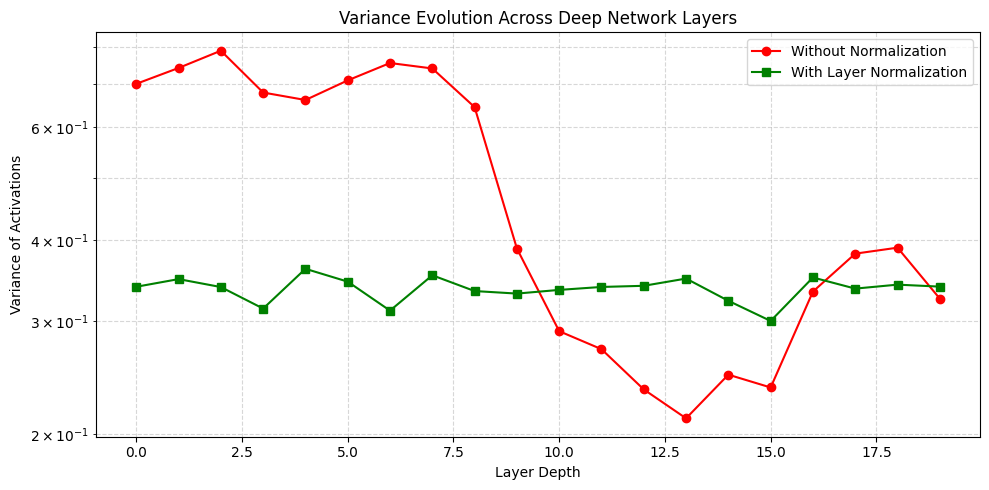

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Experimento comparando o comportamento de forward sem e com normalização.
def simulate_deep_network(use_norm=False, depth=20, dim=256):
    x = torch.randn(32, dim)  # Input fixo
    variances = []

    # Simula as múltiplas camadas de uma MLP
    for _ in range(depth):
        # Mapeamento linear com inicialização normal
        layer = nn.Linear(dim, dim, bias=False)
        nn.init.normal_(layer.weight, mean=0.0, std=np.sqrt(2.0 / dim))

        x = layer(x)
        if use_norm:
            norm_layer = nn.LayerNorm(dim)
            x = norm_layer(x)

        x = torch.relu(x)
        variances.append(x.var().item())

    return variances

# Execução com dois hiperparâmetros categóricos diferentes (bool norm)
vars_no_norm = simulate_deep_network(use_norm=False)
vars_with_norm = simulate_deep_network(use_norm=True)

# Visualização gráfica das respostas
plt.figure(figsize=(10, 5))
plt.plot(vars_no_norm, label='Without Normalization', color='red', marker='o')
plt.plot(vars_with_norm, label='With Layer Normalization', color='green', marker='s')

plt.title('Variance Evolution Across Deep Network Layers')
plt.xlabel('Layer Depth')
plt.ylabel('Variance of Activations')
plt.yscale('log')  # Eixo logarítmico revela a explosão aguda
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conexões com ML moderno
Esta seção reflete o impacto permanente das técnicas de normalização nas linhas de pesquisa fronteiriças da inteligência artificial aplicada em 2025.

A camada RMSNorm consolida-se de modo contínuo e permanente como o bloco vital por trás dos mais proeminentes Modelos de Linguagem de Grande Escala (LLMs), dominando os pesos arquiteturais na família Llama (Meta) e nos modelos Mistral. A principal razão para a sua hegemonia baseia-se na entrega superior ou comparável de desempenho e estabilidade quando contrastada com a Layer Normalization regular, com o custo em flops amplamente declinado mediante a remoção das operações de cálculo e subtração de média da fórmula originária.

Adicionalmente, novos e inovadores conceitos persistem desafiando esse layout, com pesquisas de 2025 avançando sobre as restrições baseadas em desvio padrão e migrando ao terreno ativacional experimental. Uma iniciativa marcante propôs a técnica Dynamic Tanh, valendo-se do mapeamento de saídas da camada linear operando no espaço dimensional da ativação tangente modificada em prol da máxima otimização temporal na propagação sem depender de parâmetros estatísticos globais.

- **RMSNorm (Root Mean Square Layer Normalization):** Simplifica e estabiliza dinâmicas sequenciais em processamento de texto.
- **Dynamic Tanh (Meta, 2025):** Propõe um substituto veloz ignorando estatísticas latentes para alinhamento focado na performance crua do tensor.

## 9. Exercícios
Esta seção firma os tópicos expostos submetendo instâncias lógicas e implementações arquiteturais para a sua resolução crítica.

**Exercício 1: Diferença Prática no Modo de Treino/Inferência (Resolvido)**
*Pergunta:* Por que uma camada de Batch Normalization comporta-se diferente quando o modelo se encontra em .train() ou em .eval() e como isso afeta a predição?

*Solução:* Durante a propagação na fase de treinamento (.train()), a métrica da Batch Normalization captura rigorosamente a média e a variância da amostragem (mini-batch) injetada momentaneamente na rede. Entretanto, em fase de avaliação ou teste (.eval()), os dados não servem para aprendizado. Como a amostra pode ser individual, usar sua métrica particular descalibraria o modelo. Assim, no modo avaliação, ela desabilita as estatísticas da amostra e passa a usar os limites globais históricos estritamente guardados durante a fase inteira de treino (médias móveis). Se submetido incorretamente no momento errado, o tensor resultante apresentará ruídos aleatórios na predição.

**Exercício 2: Demonstração Manual Z-Score (Resolvido)**
*Pergunta:* Calcule a matriz normalizada utilizando normalização Z-Score (Batch Norm para um único atributo) para o lote de ativações $X = [2.0, 4.0, 6.0, 8.0]$.

*Solução:*
1) Computa-se a média $\mu$: $(2+4+6+8)/4 = 20/4 = 5.0$.
2) Computa-se a variância base (desvio das médias):
$v_1 = (2-5)^2 = 9$
$v_2 = (4-5)^2 = 1$
$v_3 = (6-5)^2 = 1$
$v_4 = (8-5)^2 = 9$
Média da variância: $\sigma^2 = (9+1+1+9) / 4 = 20 / 4 = 5.0$.
3) O desvio padrão: $\sigma = \sqrt{5.0} \approx 2.236$.
4) Valor Normalizado ($X_{norm} = \frac{x - 5}{2.236}$):
$X_{norm} \approx [-1.34, -0.44, 0.44, 1.34]$.

**Exercício 3: Alternativa Computacional (Resolvido)**
*Pergunta:* Implemente em PyTorch a variação Dynamic Tanh demonstrando sua ativação para uso generalizado conforme propostas recentes em LLMs.

*Solução:*
```python
import torch
import torch.nn as nn

class DynamicTanhNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Alpha é responsável por determinar a inclinação (smoothness) da ativação.
        self.alpha = nn.Parameter(torch.ones(1))
        # Parâmetros de escala e deslocamento tradicionais
        self.gamma = nn.Parameter(torch.ones(dim))
        self.beta = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        # A normalização mapeia puramente no formato da tangente adaptável da pesquisa Meta (2025).
        return self.gamma * torch.tanh(self.alpha * x) + self.beta
```

**Desafio 1 (Aberto):**
A técnica conhecida como Group Normalization agrupa e intercala a eficiência da Layer com a granularidade da Instance Normalization. Escreva uma classe NumpyGroupNorm dividindo explicitamente o tensor simulando canais em um número N fixo de agrupamentos independentes e calcule os tensores médios para cada particionamento.

**Desafio 2 (Aberto):**
O hiperparâmetro de inicialização da variável $\alpha$ na Dynamic Tanh regula rigorosamente a rigidez inicial do vetor na predição sem supervisão dos blocos iniciais do otimizador. Crie um experimento desenhando múltiplas redes neurais cujas instâncias iniciais de $\alpha$ se dividem em $0.001$, $1.0$ e $100.0$. Obtenha os gráficos e discuta como o parâmetro subverte ou paralisa os gradientes fluídos comparado a ativações tradicionais.